 Dimensions 
Lignes : 900 | Colonnes : 8

 Aperçu des 5 premières lignes
    N   P   K  temperature   humidity        ph     rainfall     label
0  61  52  41    24.976695  83.891805  6.880431   204.800185      rice
1  80  80  76    24.370000  82.470000  6.590000  1530.600000  plantain
2  32  11  31    25.068720  93.314104  6.205932   134.841907   coconut
3  31  30  27    25.880000  77.640000  6.480000  1812.760000     cacao
4  63  44  41    24.172988  83.728757  5.583370   257.034355      rice

 Types de colonnes
N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label              str
dtype: object

 Valeurs manquantes
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

 Doublons
Nombre de doublons : 0

 Distribution des classes (cultures)
label
rice        100
plantain    100
coc

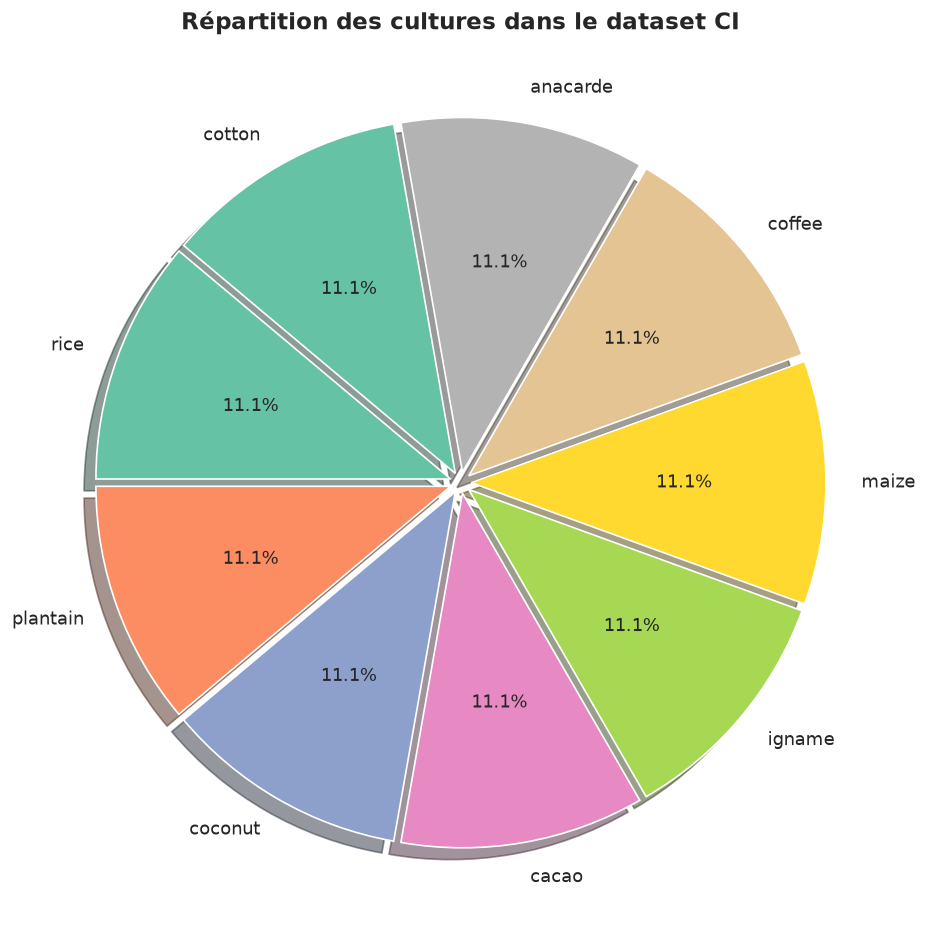

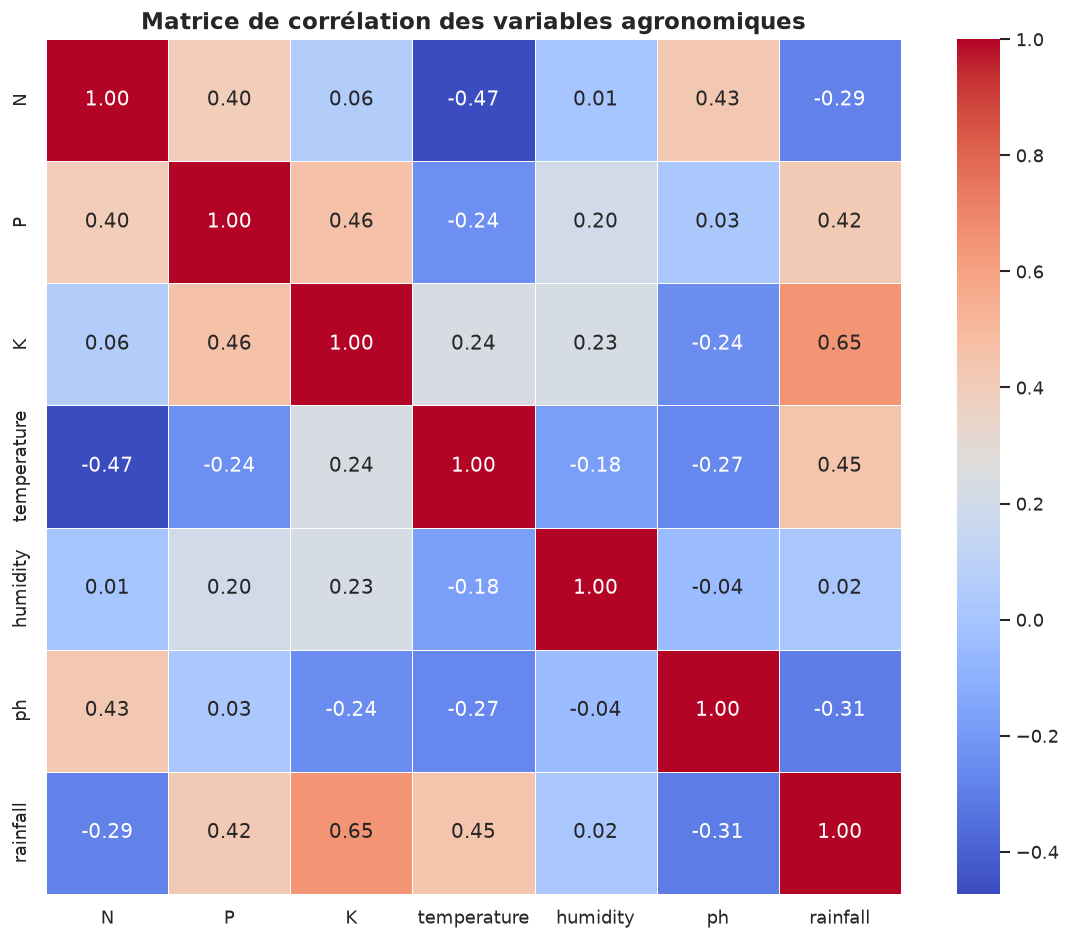

/tmp/ipykernel_2098/3198229550.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_2098/3198229550.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


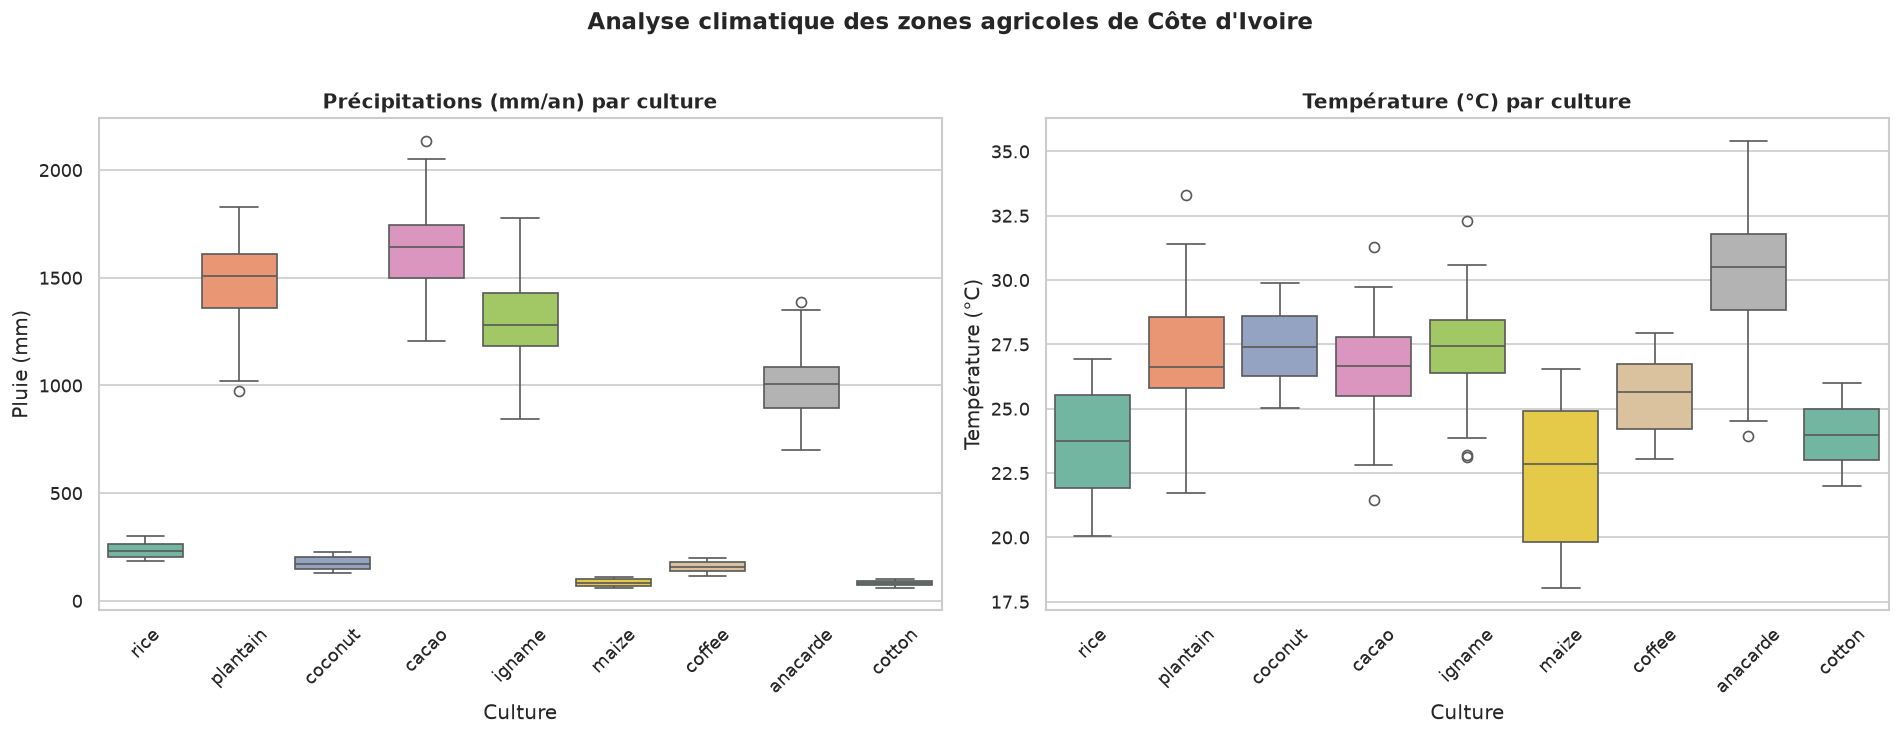

/tmp/ipykernel_2098/3198229550.py:116: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_2098/3198229550.py:116: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_2098/3198229550.py:116: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


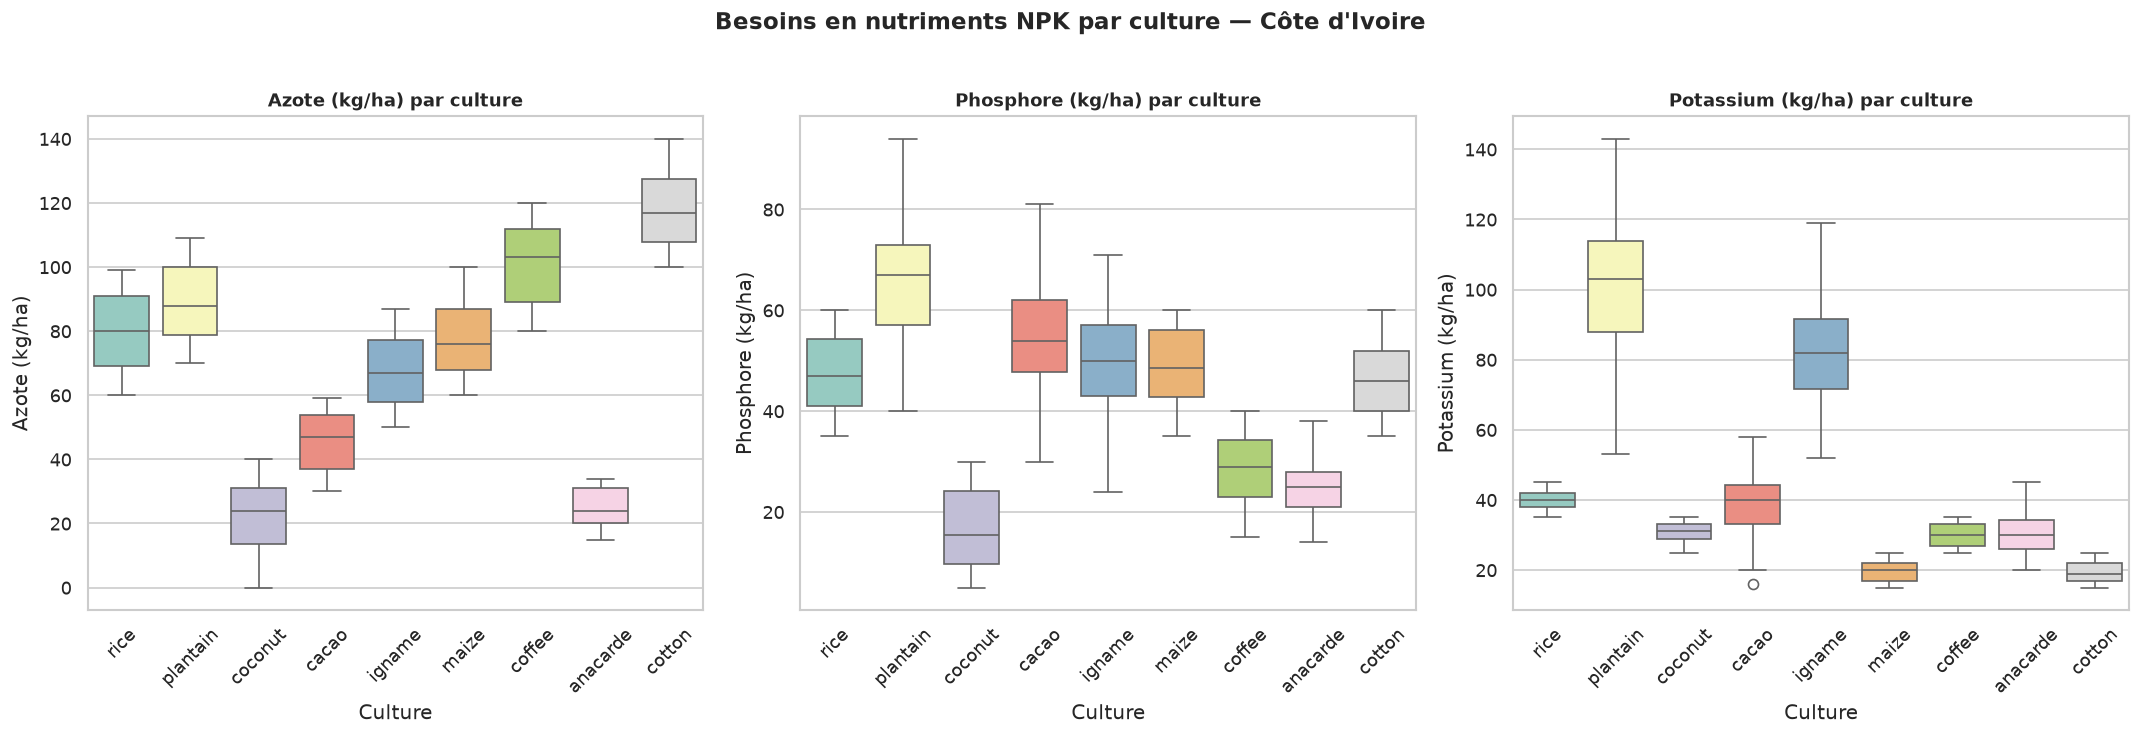

/tmp/ipykernel_2098/3198229550.py:134: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_2098/3198229550.py:145: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


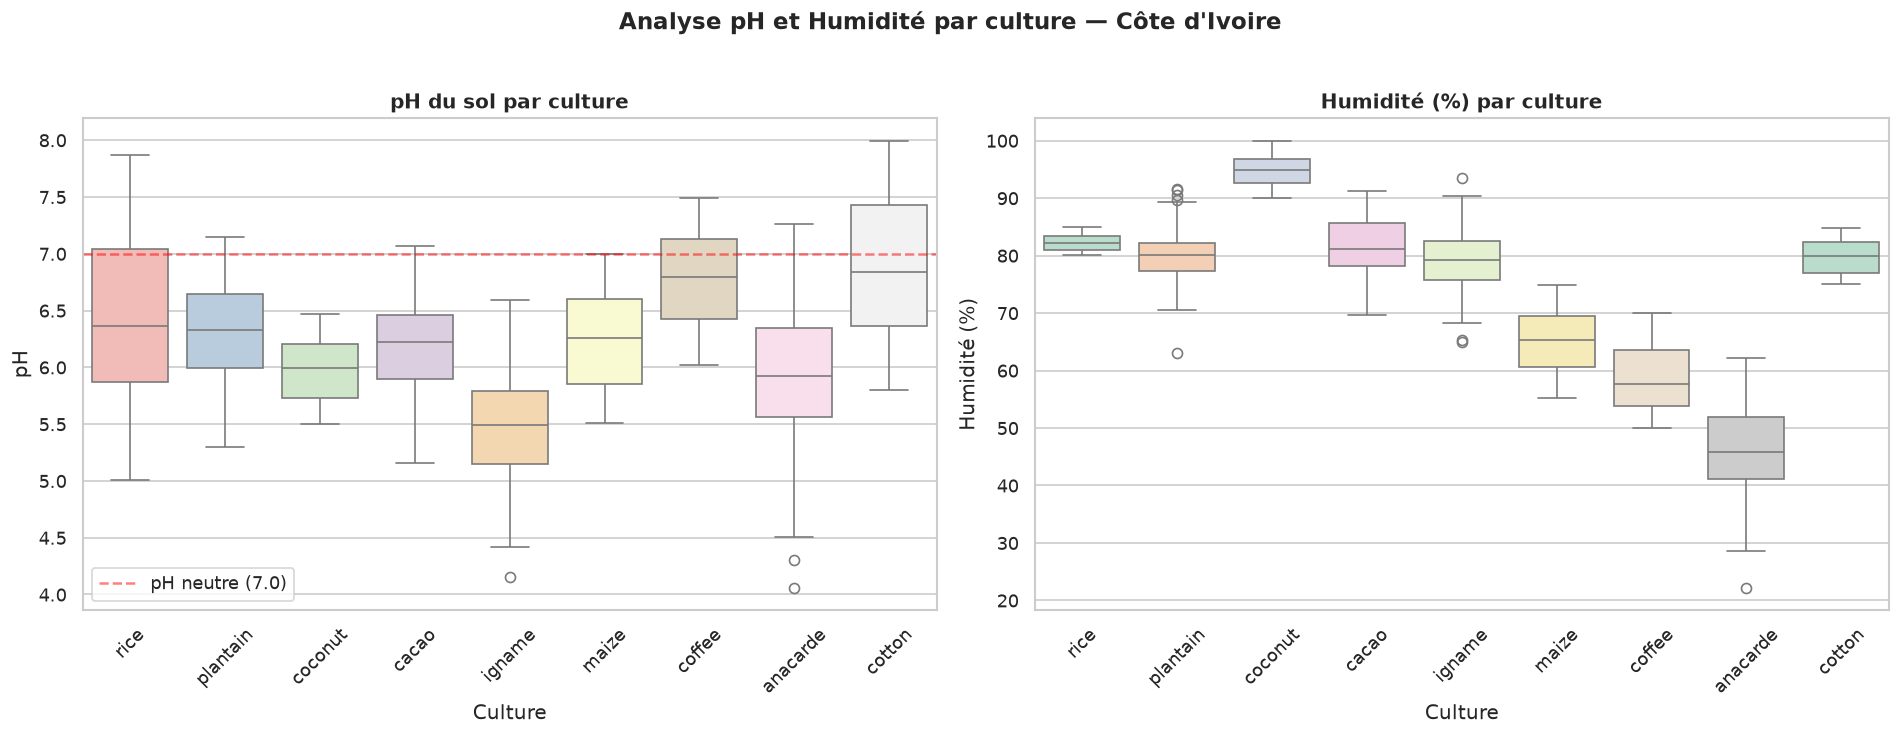

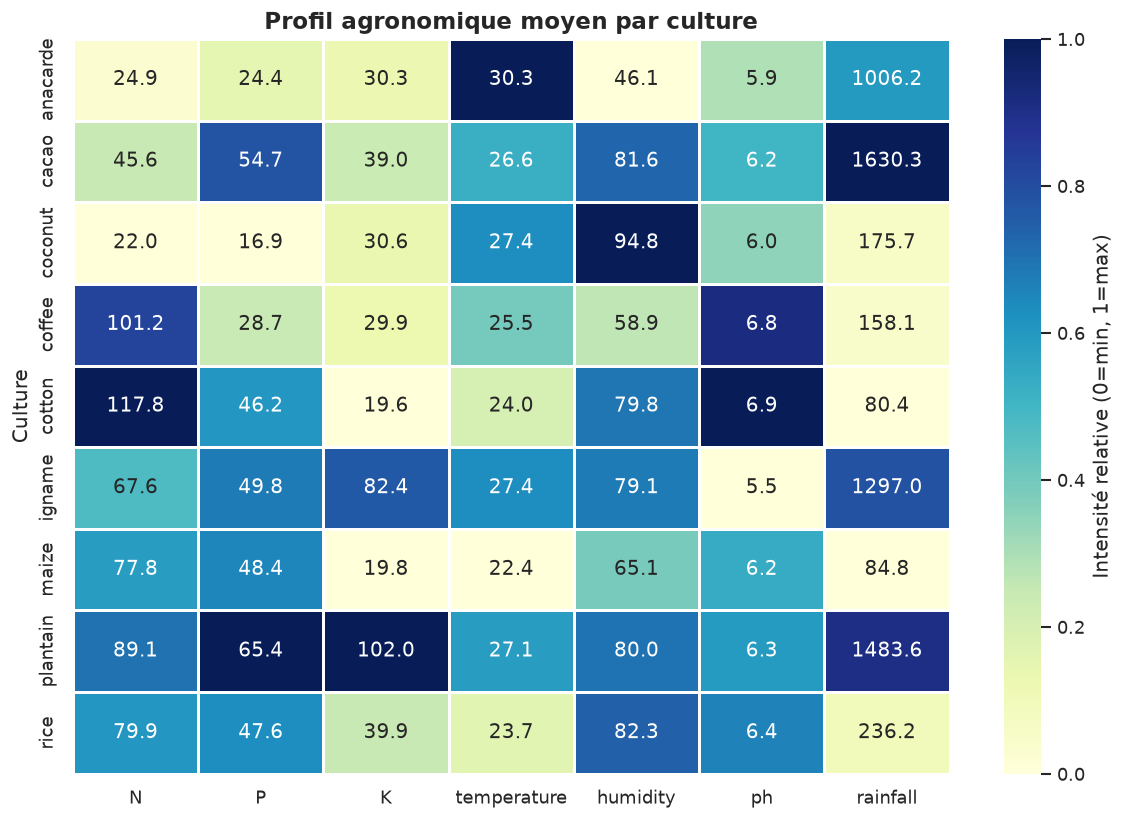

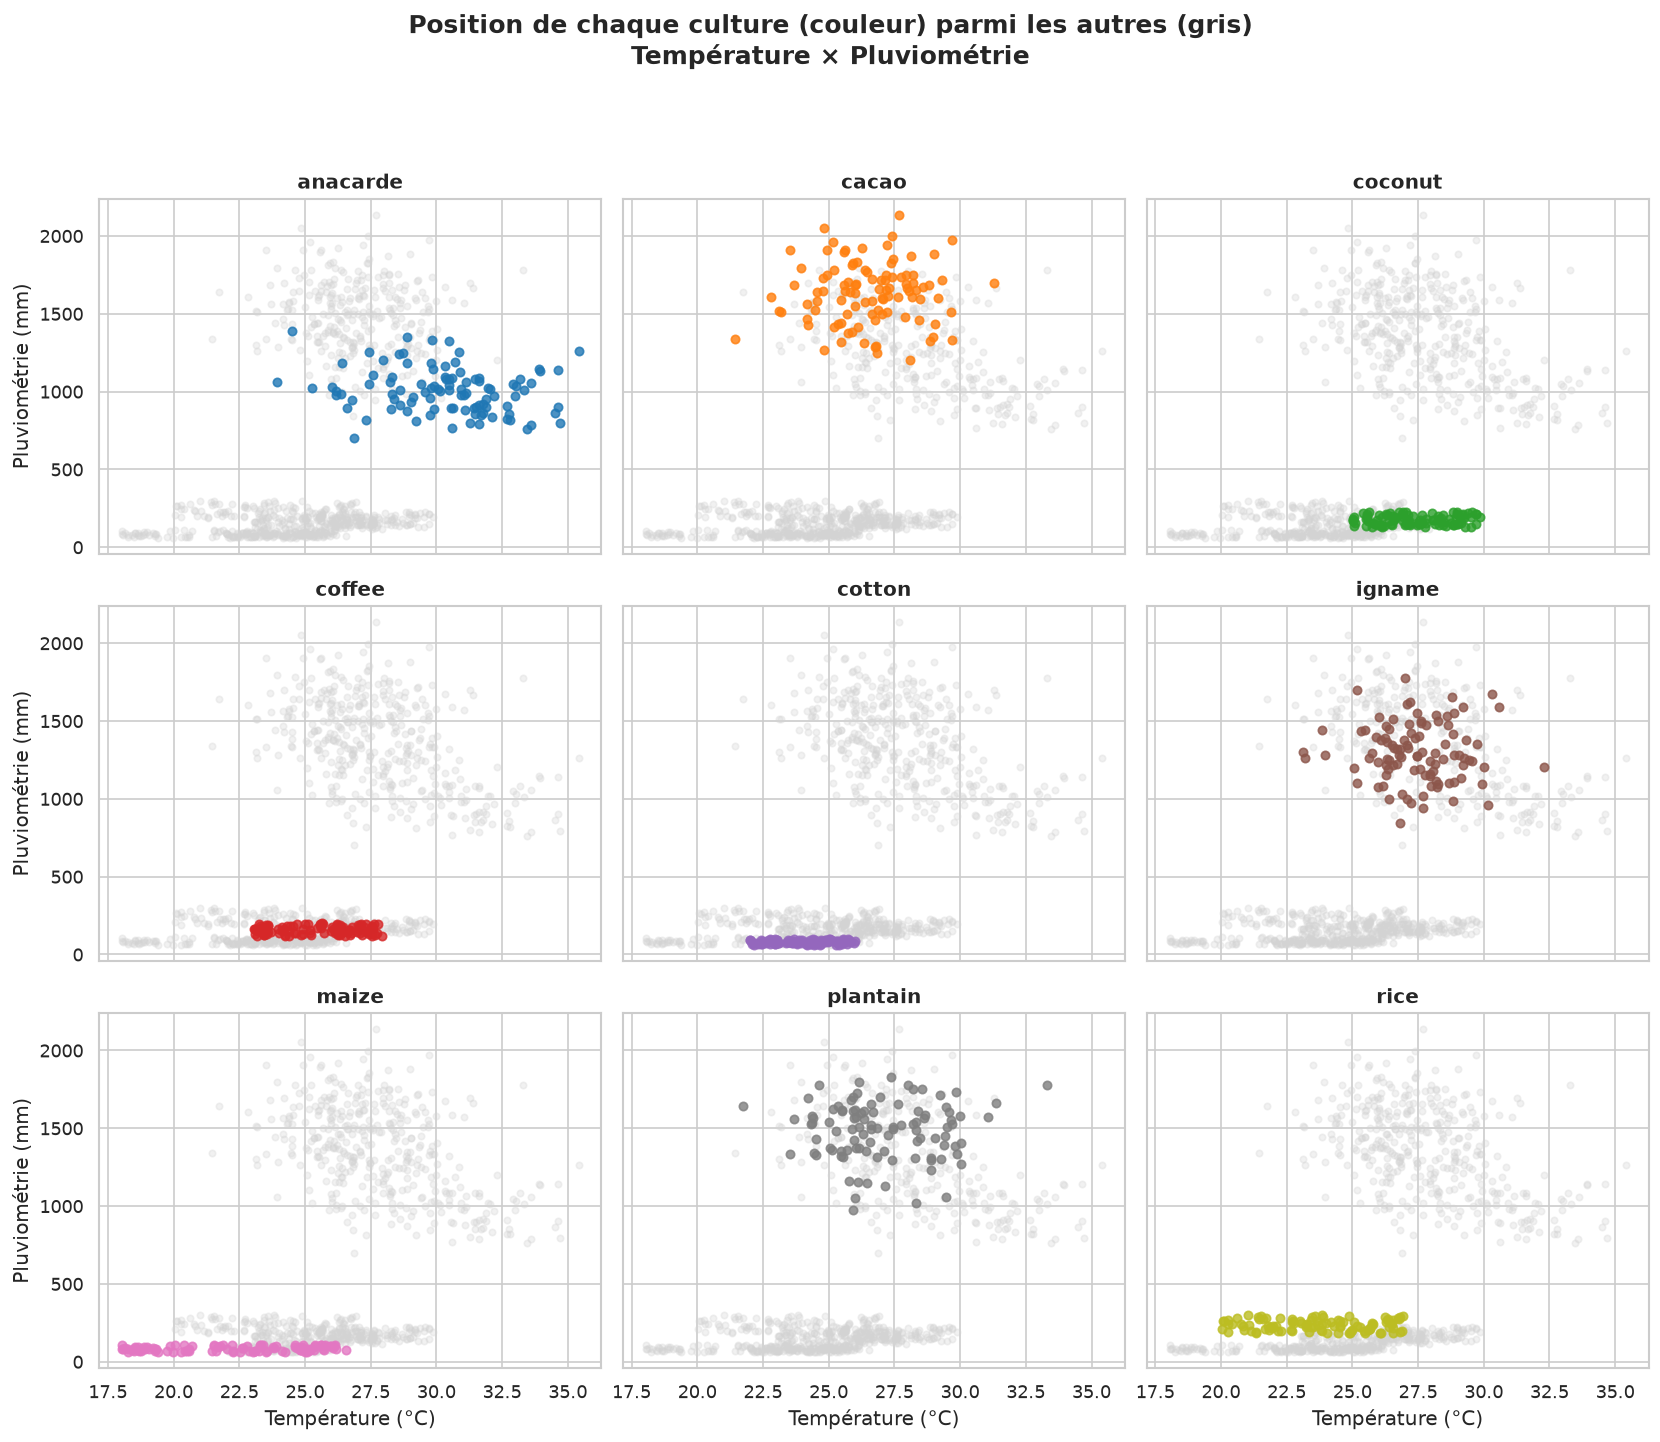

In [ ]:
# Analyse Exploratoire des Données (EDA)
# Dataset : dataset_agricole_ci_final.csv (9 cultures, 1000 lignes)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.dpi'] = 120

# 1. CHARGEMENT ET VÉRIFICATIONS DE BASE

df = pd.read_csv('../data/dataset_agricole_ci_final.csv')

print(" Dimensions ")
print(f"Lignes : {df.shape[0]} | Colonnes : {df.shape[1]}")

print("\n Aperçu des 5 premières lignes")
print(df.head())

print("\n Types de colonnes")
print(df.dtypes)

print("\n Valeurs manquantes")
print(df.isnull().sum())

print("\n Doublons")
print(f"Nombre de doublons : {df.duplicated().sum()}")

print("\n Distribution des classes (cultures)")
print(df['label'].value_counts())

# 2. STATISTIQUES DESCRIPTIVES PAR CULTURE

print("\n Statistiques générales ")
print(df.describe().round(2))

print("\n Moyennes par culture ")
print(df.groupby('label').mean().round(2))

# 3. VISUALISATION 1 - Distribution des cultures (camembert)

plt.figure(figsize=(8, 8))
counts = df['label'].value_counts()
colors = sns.color_palette("Set2", len(counts))
plt.pie(
    counts.values,
    labels=counts.index,
    colors=colors,
    autopct='%1.1f%%',
    startangle=140,
    explode=[0.03] * len(counts),
    shadow=True,
    textprops={'fontsize': 11}
)
plt.title("Répartition des cultures dans le dataset CI", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# 4. VISUALISATION 2 - Matrice de corrélation
# Objectif : voir quelles variables sont liées entre elles


plt.figure(figsize=(10, 8))
corr = df.drop(columns=['label']).corr()
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    square=True
)
plt.title("Matrice de corrélation des variables agronomiques", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 5. VISUALISATION 3 - Boxplots Pluie et Température par culture
# Objectif : prouver que les zones climatiques CI sont bien séparées
# (Sud forestier humide vs Nord sec)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(
    data=df, x='label', y='rainfall',
    ax=axes[0], palette='Set2', order=df['label'].unique()
)
axes[0].set_title("Précipitations (mm/an) par culture", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Culture")
axes[0].set_ylabel("Pluie (mm)")
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(
    data=df, x='label', y='temperature',
    ax=axes[1], palette='Set2', order=df['label'].unique()
)
axes[1].set_title("Température (°C) par culture", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Culture")
axes[1].set_ylabel("Température (°C)")
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle("Analyse climatique des zones agricoles de Côte d'Ivoire",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 6. VISUALISATION 4 - Boxplots NPK par culture
# Objectif : montrer que les besoins en nutriments varient selon la culture

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
nutriments = [('N', 'Azote (kg/ha)'), ('P', 'Phosphore (kg/ha)'), ('K', 'Potassium (kg/ha)')]

for ax, (col, ylabel) in zip(axes, nutriments):
    sns.boxplot(
        data=df, x='label', y=col,
        ax=ax, palette='Set3', order=df['label'].unique()
    )
    ax.set_title(f"{ylabel} par culture", fontsize=11, fontweight='bold')
    ax.set_xlabel("Culture")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle("Besoins en nutriments NPK par culture - Côte d'Ivoire",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 7. VISUALISATION 5 - Distribution pH et Humidité par culture

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(
    data=df, x='label', y='ph',
    ax=axes[0], palette='Pastel1', order=df['label'].unique()
)
axes[0].set_title("pH du sol par culture", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Culture")
axes[0].set_ylabel("pH")
axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(y=7.0, color='red', linestyle='--', alpha=0.5, label='pH neutre (7.0)')
axes[0].legend()

sns.boxplot(
    data=df, x='label', y='humidity',
    ax=axes[1], palette='Pastel2', order=df['label'].unique()
)
axes[1].set_title("Humidité (%) par culture", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Culture")
axes[1].set_ylabel("Humidité (%)")
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle("Analyse pH et Humidité par culture - Côte d'Ivoire",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 8. VISUALISATION 6 - Heatmap des moyennes normalisées par culture

features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
df_moyennes = df.groupby('label')[features].mean()

# Normalisation 0-1 pour rendre les échelles comparables (kg/ha vs °C vs mm)
df_norm = (df_moyennes - df_moyennes.min()) / (df_moyennes.max() - df_moyennes.min())

plt.figure(figsize=(10, 7))
sns.heatmap(
    df_norm,
    annot=df_moyennes.round(1),  # affiche les vraies valeurs, pas les normalisées
    fmt='.1f',
    cmap='YlGnBu',
    linewidths=0.8,
    cbar_kws={'label': 'Intensité relative (0=min, 1=max)'}
)
plt.title("Profil agronomique moyen par culture", fontsize=14, fontweight='bold')
plt.xlabel("")
plt.ylabel("Culture")
plt.tight_layout()
plt.show()

# 9. VISUALISATION 7 - Petits multiples Température × Pluviométrie

ordre_cultures = sorted(df['label'].unique())
palette = sns.color_palette("tab10", len(ordre_cultures))

fig, axes = plt.subplots(3, 3, figsize=(14, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i, culture in enumerate(ordre_cultures):
    ax = axes[i]

    # Toutes les autres cultures en gris clair (contexte)
    autres = df[df['label'] != culture]
    ax.scatter(autres['temperature'], autres['rainfall'],
               color='lightgray', alpha=0.3, s=15)

    # La culture ciblée en couleur vive
    cible = df[df['label'] == culture]
    ax.scatter(cible['temperature'], cible['rainfall'],
               color=palette[i], alpha=0.8, s=25)

    ax.set_title(culture, fontsize=12, fontweight='bold')
    ax.set_xlabel("Température (°C)" if i >= 6 else "")
    ax.set_ylabel("Pluviométrie (mm)" if i % 3 == 0 else "")

fig.suptitle("Position de chaque culture (couleur) parmi les autres (gris)\nTempérature × Pluviométrie",
             fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()